In [1]:
import sys
sys.path.append('/Users/zihaolin/Desktop/Neutrino/RLRTworkdir/RLRTExtraction')

from analysis.plotting import plot_response_qvbin, plot_response_q2bin
from analysis.presets import *
from analysis.plotting import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator


In [15]:
# read this analysis extracted RL RT; presets
this_analysis_qv = pd.read_excel('/Users/zihaolin/Desktop/Neutrino/RLRTworkdir/RLRTExtraction/Carbon/one_sheet_to_rule_them_all.xlsx', sheet_name='this_analysis_qvbin')
this_analysis_q2 = pd.read_excel('/Users/zihaolin/Desktop/Neutrino/RLRTworkdir/RLRTExtraction/Carbon/one_sheet_to_rule_them_all.xlsx', sheet_name='this_analysis_q2bin')
# this_analysis_qv = this_analysis_qv.loc[ (this_analysis_qv['qvcenter']>0.3) | (this_analysis_qv['ex']>=0.025)]
# this_analysis_q2 = this_analysis_q2.loc[this_analysis_q2['ex']>=0.03]

plot_xlsx = '/Users/zihaolin/Desktop/Neutrino/RLRTworkdir/RLRTExtraction/Carbon/one_sheet_to_rule_them_all.xlsx'
pdf_path = '/Users/zihaolin/Desktop/Neutrino/RLRTworkdir/RLRTExtraction/Carbon/12C_plots/RLRT_PRD'

def save_to_pdf(fig, filename):
    with PdfPages(f'{pdf_path}/{filename}') as pdf:
        pdf.savefig(fig, bbox_inches='tight')

def plot_response_q2bin_ex_region(qtype):
    theory_plot_list = ['ED-RMF', 'GFMC', 'STA-QMC']
    exp_plot_list = ['Goldemberg', 'Baran','Yamaguchi', 'Photo-production']
    plot_xlsx='/Users/zihaolin/Desktop/Neutrino/RLRTworkdir/RLRTExtraction/Carbon/one_sheet_to_rule_them_all.xlsx'
    if qtype == 'qv':
        qcenters = [0.1, 0.148, 0.167, 0.205, 0.24, 0.3, 0.38, 0.57]
    else:
        qcenters = [0.01, 0.02, 0.026, 0.04, 0.056, 0.093, 0.12, 0.16]

    RLRT_PLOT_HEIGHTS = {
        0.1:[80.0,14],
        0.148:[90.0,27],
        0.167:[80.0,30],
        0.205:[99.9,35],
        0.24:[110.0,41],
        0.3:[65.0,44],
        0.38:[18.0,25],
        0.57:[0.8,3.5],
        0.01:[80,15],
        0.02:[80,27],
        0.026:[80,30],
        0.04:[99.9,35],
        0.056:[110,41],
        0.093:[60,45],
        0.12:[32,28],
        0.16:[15,20],
    }

    sheet_CBfit = pd.read_excel(plot_xlsx, sheet_name=f'CBfit_{qtype}bin_low_ex')
    sheet_exp_rl = pd.read_excel(plot_xlsx, sheet_name=f'exp_rl_{qtype}bin')
    sheet_exp_rt = pd.read_excel(plot_xlsx, sheet_name=f'exp_rt_{qtype}bin')
    sheet_theory_rl = pd.read_excel(plot_xlsx, sheet_name=f'theory_rl_{qtype}bin')
    sheet_theory_rt = pd.read_excel(plot_xlsx, sheet_name=f'theory_rt_{qtype}bin')
    df_this_analysis = pd.read_excel(plot_xlsx, sheet_name=f'this_analysis_{qtype}bin')
    
    handles = []
    labels = []

    def nu_to_ex(qtype, nu, qcenter):
        a = 12
        if qtype == 'qv':
            qv = qcenter
            q2 = qv**2 - nu**2
        else:
            q2 = qcenter
        nuel = q2 / (2.0 * (0.931494 * a))
        ex = nu - nuel
        return ex

    # helper function to plot on given axes
    def plot_on_rlrt_subplots(ax_rl, ax_rt, qtype, qcenter):

        # plot Christy Bodek fit
        ChristyBodekFit = sheet_CBfit.loc[sheet_CBfit[qtype]==qcenter].copy()
        ax_rl.plot(ChristyBodekFit['ex'],ChristyBodekFit["rltot"],color='black',label="$R_L$(total), $R_T$(total) Christy-Bodek-2026", linestyle='solid',lw=0.8, zorder=0)
        ax_rt.plot(ChristyBodekFit['ex'],ChristyBodekFit["rttot"], color='black', linestyle='solid',lw=0.8, zorder=0)
        ax_rl.plot(ChristyBodekFit['ex'],ChristyBodekFit["rlqe"], color='black',label="$R_L$(QE), $R_T$(QE+TE) Christy-Bodek-2026", linestyle='dotted',lw=0.8, zorder=0)
        ax_rt.plot(ChristyBodekFit['ex'],ChristyBodekFit["rtqe"] + ChristyBodekFit["rte"], color='black', linestyle='dotted',lw=0.8, zorder=0)


        # plot theory as lines
        for theory in theory_plot_list:
            df_rl = sheet_theory_rl.loc[(sheet_theory_rl[qtype]==qcenter) & (sheet_theory_rl['theory']==theory)].copy()
            df_rl['ex'] = nu_to_ex(qtype, df_rl['nu'], qcenter)
            ax_rl.plot(df_rl['ex'], df_rl['rl'], **LINE_STYLES[theory], label=f'$R_L$, $R_T$ {theory}')

            df_rt = sheet_theory_rt.loc[(sheet_theory_rt[qtype]==qcenter) & (sheet_theory_rt['theory']==theory)].copy()
            df_rt['ex'] = nu_to_ex(qtype, df_rt['nu'], qcenter)
            ax_rt.plot(df_rt['ex'], df_rt['rt'], **LINE_STYLES[theory])
     
        # plot experiment data as scatter and error bars
        for exp in exp_plot_list:
            df_rl = sheet_exp_rl.loc[(sheet_exp_rl[qtype]==qcenter) & (sheet_exp_rl['experiment']==exp)].copy()
            df_rt = sheet_exp_rt.loc[(sheet_exp_rt[qtype]==qcenter) & (sheet_exp_rt['experiment']==exp)].copy()
            df_rl['ex'] = nu_to_ex(qtype, df_rl['nu'], qcenter)
            df_rt['ex'] = nu_to_ex(qtype, df_rt['nu'], qcenter)

            if len(df_rl) > 0:
                ax_rl.errorbar(df_rl['ex'], df_rl['rl'], yerr=df_rl['rlerr'], **ERRORBAR_STYLES[exp])
                ax_rl.scatter(df_rl['ex'], df_rl['rl'], **SCATTER_STYLES[exp])
            if len(df_rt) > 0:
                ax_rt.errorbar(df_rt['ex'], df_rt['rt'], yerr=df_rt['rterr'], **ERRORBAR_STYLES[exp])
                ax_rt.scatter(df_rt['ex'], df_rt['rt'], **SCATTER_STYLES[exp], label=f'$R_L$, $R_T$ {exp}')
                if exp == 'Photo-production':
                   ax_rt.plot(df_rt['ex'], df_rt['rt'], color='gray', linewidth=0.5, zorder=-2)


        # plot this analysis
        df_qvbin = df_this_analysis.loc[df_this_analysis[f'{qtype}center'] == qcenter]
        if qcenter == 0.38 or ( qtype == 'q2' and (qcenter > 0.01  and qcenter <= 0.16)):
            df_qvbin = df_qvbin.loc[df_qvbin['ex']>=0.03]
        if qcenter in [0.148,0.167,0.205,0.24,0.3] or qcenter in [0.020, 0.026, 0.040, 0.056, 0.093]:
            # avoid overlapping with Yamaguchi
            nu_yam = sheet_exp_rl.loc[(sheet_exp_rl[qtype]==qcenter) & (sheet_exp_rl['experiment']=='Yamaguchi')]['nu'].max()
            ex_yam = nu_to_ex(qtype, nu_yam, qcenter)
            df_qvbin = df_qvbin.loc[df_qvbin['ex'] >= ex_yam]

        ax_rl.errorbar(df_qvbin['ex'], df_qvbin['rl'], yerr = df_qvbin['rlerr'], ecolor='red', markersize=0, capsize=0, lw=1, fmt='D', elinewidth=1, alpha=0.5, zorder=2) 
        ax_rl.scatter(df_qvbin['ex'], df_qvbin['rl'], color='red', label = '$R_L$, $R_T$ this analysis', marker='D', s=15, edgecolors='gray', linewidth=0.5, zorder=2)
        ax_rt.errorbar(df_qvbin['ex'], df_qvbin['rt'], yerr = df_qvbin['rterr'], ecolor='red', markersize=0, capsize=0, lw=1, fmt='D', elinewidth=1, alpha=0.5, zorder=2)
        ax_rt.scatter(df_qvbin['ex'], df_qvbin['rt'], color='red', marker='D', s=15, edgecolors='gray', linewidth=0.5, zorder=2)

        ax_rl.set_xlim(0,0.06)
        ax_rt.set_xlim(0,0.06)

        ax_rl.set_ylim(0,RLRT_PLOT_HEIGHTS[qcenter][0])
        ax_rt.set_ylim(0,RLRT_PLOT_HEIGHTS[qcenter][1])


        ax_rl.minorticks_on()
        ax_rl.tick_params(which='both', direction='in', top=True, right=True)
        ax_rt.minorticks_on()
        ax_rt.tick_params(which='both', direction='in', top=True, right=True)
        if qcenter == 0.16:
            ax_rt.yaxis.set_major_locator(MaxNLocator(integer=True))
        
        ax_rl.set_ylabel(r'$R_L$ (GeV$^{-1}$)')
        ax_rt.set_ylabel(r'$R_T$ (GeV$^{-1}$)')

        if qtype == 'qv':
            ax_rl.text(0.95, 0.95,'$R_L$ ($|\mathbf{q}|$ = '+f'{qcenter} GeV/c)',transform=ax_rl.transAxes,ha='right',va='top',color='gray')
            ax_rt.text(0.95, 0.95,'$R_T$ ($|\mathbf{q}|$ = '+f'{qcenter} GeV/c)',transform=ax_rt.transAxes,ha='right',va='top',color='gray')
        else:
            ax_rl.text(0.95, 0.95,'$R_L$ ($Q^2$ = '+f'{qcenter} GeV$^2$/c$^2$)',transform=ax_rl.transAxes,ha='right',va='top',color='gray')
            ax_rt.text(0.95, 0.95,'$R_T$ ($Q^2$ = '+f'{qcenter} GeV$^2$/c$^2$)',transform=ax_rt.transAxes,ha='right',va='top',color='gray')


        # handle legend labels
        h, l = ax_rl.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        h, l = ax_rt.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(16, 16), dpi=200)
    axs_flat = axs.flatten()

    for i in range(8):
        qcenter = qcenters[i]
        ax_rl = axs_flat[i*2]
        ax_rt = axs_flat[i*2+1]
        plot_on_rlrt_subplots(ax_rl, ax_rt, qtype=qtype, qcenter=qcenter)
        if i in [6, 7]:
            ax_rl.set_xlabel('$E_x$ (GeV)')
            ax_rt.set_xlabel('$E_x$ (GeV)')
    unique = dict(zip(labels, handles))
    handles = list(unique.values())
    labels = list(unique.keys())
    fig.legend(handles, labels, loc="lower center", ncol=4, 
               bbox_to_anchor=(0.5, 0.03), 
               frameon=False)

    plt.show()

    return fig



#### Fig 7: 3 $\mathbf{q}$ bins and 1 $Q^2$ bin with previous experiment comparison
#### Fig 8, 9, 10: $\mathbf{q}$ bins with theory comparison
#### Fig 11: $\mathbf{q}$ bins ex region
#### Fig 12, 13, 14, 15: $\mathbf{q}$ bins with MC comparison
#### Fig 16, 17, 18, 19: $Q^2$ bin with EDRMF and NuWro comparison
#### Fig 20: $Q^2$ bin ex region
#### Fig 21, 22, 23, 24: $\mathbf{q}$ bins with EDRMF, SuSAv2 cocmparison
#### Fig 25, 26, 27, 28: $Q^2$ bin with EDRMF, SuSAv2 comparison


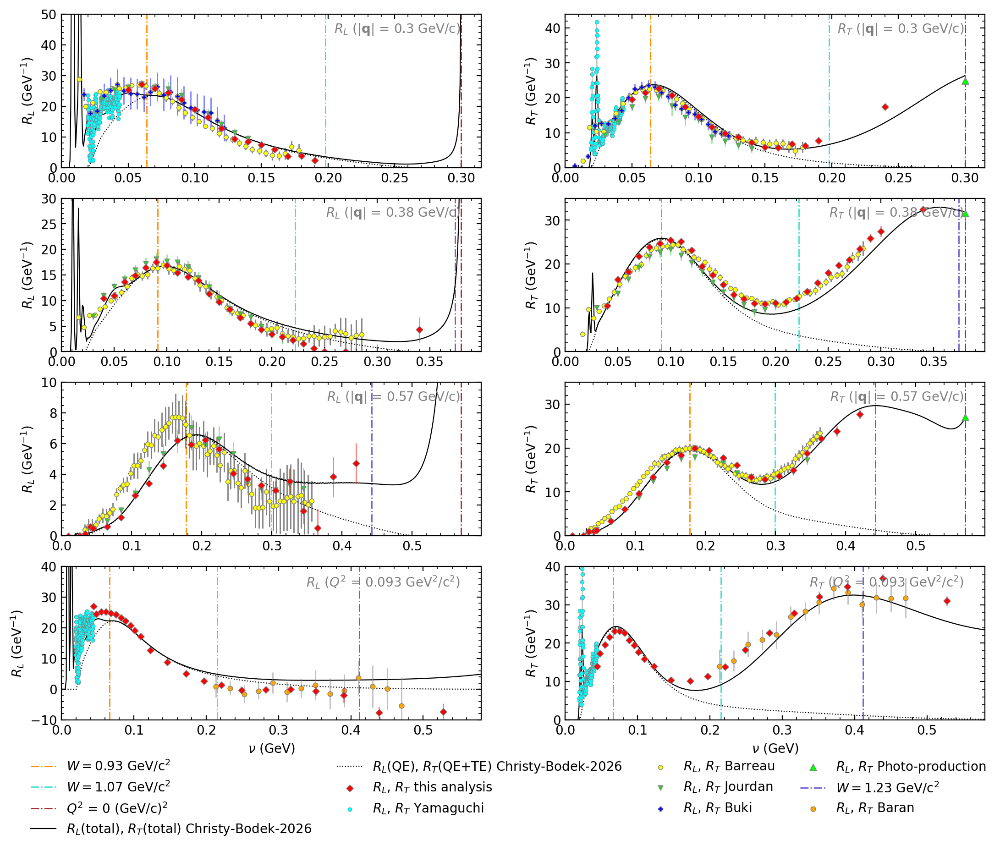

In [3]:
# fig 7

# plot qv = 0.3, 0.38, 0.57:
qvcenters = [0.3, 0.38, 0.57]
mc_plot_list = []
theory_plot_list = []
exp_plot_list = EXP_QVPLOT_LIST

fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(13, 10), dpi=200, sharex=False, squeeze=False)
handles = []
labels = []

plot_xlsx = '/Users/zihaolin/Desktop/Neutrino/RLRTworkdir/RLRTExtraction/Carbon/one_sheet_to_rule_them_all.xlsx'
sheet_CBfit = pd.read_excel(plot_xlsx, sheet_name='CBfit_qvbin')
sheet_exp_rl = pd.read_excel(plot_xlsx, sheet_name='exp_rl_qvbin')
sheet_exp_rt = pd.read_excel(plot_xlsx, sheet_name='exp_rt_qvbin')


# helper function to plot on given axes
def plot_on_rlrt_subplots(ax_rl, ax_rt, qvcenter):
    # plot vertical dash lines at w = 0.93, 1.07, 1.23 GeV/c^2
    for w in W_PLOT_LIST:
        nu_w = 0.025 - MASS_NUCLEON + np.sqrt(qvcenter**2 + w**2)
        if nu_w < qvcenter:
            ax_rl.axvline(x = nu_w, color = W_PLOT_COLORS[w], linestyle = 'dashdot', lw = 1, label = f'$W={w}$ GeV/c$^2$', zorder=-2)
            ax_rt.axvline(x = nu_w, color = W_PLOT_COLORS[w], linestyle = 'dashdot', lw = 1, zorder=-2)

    # plot q2 = 0 vertical dash line
    ax_rl.axvline(x=qvcenter, color = 'brown', linestyle='dashdot',lw=1,label=f'$Q^2$ = 0 (GeV/c)$^2$')
    ax_rt.axvline(x=qvcenter, color = 'brown', linestyle='dashdot',lw=1)

    # plot Christy Bodek fit
    # 25 Sep 25: shift inelastic to left by 18 MeV; 25 July 18: RT quasi deuteron added
    #  FIXME: 26 May 7 inelastic peak shift is removed for now. address later.
    ChristyBodekFit = sheet_CBfit.loc[sheet_CBfit['qv']==qvcenter].copy()
    ax_rl.plot(ChristyBodekFit['nu'],ChristyBodekFit["rltot"],color='black',label="$R_L$(total), $R_T$(total) Christy-Bodek-2026", linestyle='solid',lw=0.8, zorder=0)
    ax_rt.plot(ChristyBodekFit['nu'],ChristyBodekFit["rttot"], color='black', linestyle='solid',lw=0.8, zorder=0)
    ax_rl.plot(ChristyBodekFit['nu'],ChristyBodekFit["rlqe"], color='black',label="$R_L$(QE), $R_T$(QE+TE) Christy-Bodek-2026", linestyle='dotted',lw=0.8, zorder=0)
    ax_rt.plot(ChristyBodekFit['nu'],ChristyBodekFit["rtqe"] + ChristyBodekFit["rte"], color='black', linestyle='dotted',lw=0.8, zorder=0)

    
    # plot experiment data as scatter and error bars
    for exp in exp_plot_list:
        df_rl = sheet_exp_rl.loc[(sheet_exp_rl['qv']==qvcenter) & (sheet_exp_rl['experiment']==exp)]
        df_rt = sheet_exp_rt.loc[(sheet_exp_rt['qv']==qvcenter) & (sheet_exp_rt['experiment']==exp)]
        if len(df_rl) > 0:
            ax_rl.errorbar(df_rl['nu'], df_rl['rl'], yerr=df_rl['rlerr'], **ERRORBAR_STYLES[exp])
            ax_rl.scatter(df_rl['nu'], df_rl['rl'], **SCATTER_STYLES[exp])
        if len(df_rt) > 0:
            ax_rt.errorbar(df_rt['nu'], df_rt['rt'], yerr=df_rt['rterr'], **ERRORBAR_STYLES[exp])
            ax_rt.scatter(df_rt['nu'], df_rt['rt'], **SCATTER_STYLES[exp], label=f'$R_L$, $R_T$ {exp}')

    # plot this analysis
    df_qvbin = this_analysis_qv.loc[this_analysis_qv['qvcenter'] == qvcenter]
    if qvcenter > 0.1 and qvcenter <= 0.475:
        df_qvbin = df_qvbin.loc[df_qvbin['ex']>=0.03]
    if qvcenter in [0.148,0.167,0.205,0.24,0.3]:
        # avoid overlapping with Yamaguchi
        nu_yam = sheet_exp_rl.loc[(sheet_exp_rl['qv']==qvcenter) & (sheet_exp_rl['experiment']=='Yamaguchi')]['nu'].max()
        df_qvbin = df_qvbin.loc[df_qvbin['nu'] >= nu_yam]
    ax_rl.errorbar(df_qvbin['nu'], df_qvbin['rl'], yerr = df_qvbin['rlerr'], ecolor='red', markersize=0, capsize=0, lw=1, fmt='D', elinewidth=1, alpha=0.5, zorder=2) 
    ax_rl.scatter(df_qvbin['nu'], df_qvbin['rl'], color='red', label = '$R_L$, $R_T$ this analysis', marker='D', s=15, edgecolors='gray', linewidth=0.5, zorder=2)
    ax_rt.errorbar(df_qvbin['nu'], df_qvbin['rt'], yerr = df_qvbin['rterr'], ecolor='red', markersize=0, capsize=0, lw=1, fmt='D', elinewidth=1, alpha=0.5, zorder=2)
    ax_rt.scatter(df_qvbin['nu'], df_qvbin['rt'], color='red', marker='D', s=15, edgecolors='gray', linewidth=0.5, zorder=2)

# loop over given qv centers
for i, qvcenter in enumerate(qvcenters):
    if qvcenter not in QVCENTERS:
        print(f'q={qvcenter} not in spreadsheet')
        continue

    plot_on_rlrt_subplots(axs[i, 0], axs[i, 1], qvcenter)

    # handle legend labels
    h, l = axs[i, 0].get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
    h, l = axs[i, 1].get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

    # main axs styling
    axs[i, 0].text(0.95, 0.95,'$R_L$ ($|\mathbf{q}|$ = '+f'{qvcenter} GeV/c)',transform=axs[i, 0].transAxes,ha='right',va='top',color='gray')
    axs[i, 0].tick_params(which='both', direction='in', top=True, right=True)
    axs[i, 0].minorticks_on()
    axs[i, 0].set_ylabel(r'$R_L$ (GeV$^{-1}$)')
    axs[i, 0].set_xlim(0, qvcenter*1.05)
    axs[i, 0].set_ylim(0, RLRT_QVPLOT_HEIGHTS[qvcenter][0])
    axs[i, 1].text(0.95, 0.95,'$R_T$ ($|\mathbf{q}|$ = '+f'{qvcenter} GeV/c)',transform=axs[i, 1].transAxes,ha='right',va='top',color='gray')
    axs[i, 1].tick_params(which='both', direction='in', top=True, right=True)
    axs[i, 1].minorticks_on()
    axs[i, 1].set_ylabel(r'$R_T$ (GeV$^{-1}$)')
    axs[i, 1].set_xlim(0, qvcenter*1.05)
    axs[i, 1].set_ylim(0, RLRT_QVPLOT_HEIGHTS[qvcenter][1])



# plot Q2 = 0.093
q2centers = [0.093]
exp_plot_list = EXP_Q2PLOT_LIST

# plot_xlsx = '/Users/zihaolin/Desktop/Neutrino/RLRTworkdir/RLRTExtraction/Carbon/one_sheet_to_rule_them_all.xlsx'
sheet_CBfit = pd.read_excel(plot_xlsx, sheet_name='CBfit_q2bin')
sheet_exp_rl = pd.read_excel(plot_xlsx, sheet_name='exp_rl_q2bin')
sheet_exp_rt = pd.read_excel(plot_xlsx, sheet_name='exp_rt_q2bin')

# helper function to plot on given axes
def plot_on_rl_subplots(ax_rl, q2center):
    # plot vertical dash lines at w = 0.93, 1.07, 1.23 GeV/c^2
    for w in W_PLOT_LIST:
        nu_w = 0.025 + (w**2 + q2center - MASS_NUCLEON**2)/(2 * MASS_NUCLEON)
        ax_rl.axvline(x = nu_w, color = W_PLOT_COLORS[w], linestyle = 'dashdot', lw = 1, label = f'$W={w}$ GeV/c$^2$', zorder=-2)
    nu_wmax = 0.025 + (W_PLOT_LIST[2]**2 + q2center - MASS_NUCLEON**2)/(2 * MASS_NUCLEON)

    # plot Christy Bodek fit
    # 25 Sep 25: shift inelastic to left by 18 MeV; 25 July 18: RT quasi deuteron added
    #  FIXME: 26 May 7 inelastic peak shift is removed for now. address later.
    ChristyBodekFit = sheet_CBfit.loc[sheet_CBfit['q2']==q2center].copy()
    ax_rl.plot(ChristyBodekFit['nu'],ChristyBodekFit["rltot"],color='black',label="$R_L$(total), $R_T$(total) Christy-Bodek-2026", linestyle='solid',lw=0.8, zorder=0)
    ax_rl.plot(ChristyBodekFit['nu'],ChristyBodekFit["rlqe"], color='black',label="$R_L$(QE), $R_T$(QE+TE) Christy-Bodek-2026", linestyle='dotted',lw=0.8, zorder=0)

    
    # plot experiment data as scatter and error bars
    for exp in exp_plot_list:
        df_rl = sheet_exp_rl.loc[(sheet_exp_rl['q2']==q2center) & (sheet_exp_rl['experiment']==exp)]
        if len(df_rl) > 0:
            ax_rl.errorbar(df_rl['nu'], df_rl['rl'], yerr=df_rl['rlerr'], **ERRORBAR_STYLES[exp])
            ax_rl.scatter(df_rl['nu'], df_rl['rl'], **SCATTER_STYLES[exp])

    # plot this analysis
    df_q2bin = this_analysis_q2.loc[this_analysis_q2['q2center'] == q2center]
    if q2center in [0.020, 0.026, 0.040, 0.056, 0.093]:
        # avoid overlapping with Yamaguchi
        nu_yam = sheet_exp_rl.loc[(sheet_exp_rl['q2']==q2center) & (sheet_exp_rl['experiment']=='Yamaguchi')]['nu'].max()
        df_q2bin = df_q2bin.loc[df_q2bin['nu'] >= nu_yam]
    ax_rl.errorbar(df_q2bin['nu'], df_q2bin['rl'], yerr = df_q2bin['rlerr'], ecolor='red', markersize=0, capsize=0, lw=1, fmt='D', elinewidth=1, alpha=0.5, zorder=2) 
    ax_rl.scatter(df_q2bin['nu'], df_q2bin['rl'], color='red', label = '$R_L$, $R_T$ this analysis', marker='D', s=15, edgecolors='gray', linewidth=0.5, zorder=2)
    if len(df_q2bin) > 0 and df_q2bin['nu'].max() > nu_wmax:
        xmax = df_q2bin['nu'].max()*1.1
    else:
        xmax = nu_wmax * 1.1
    axs[i, 0].set_xlim(0, xmax)
    

# helper function to plot on given axes
def plot_on_rt_subplots(ax_rt, q2center):
    # plot vertical dash lines at w = 0.93, 1.07, 1.23 GeV/c^2
    for w in W_PLOT_LIST:
        nu_w = 0.025 + (w**2 + q2center - MASS_NUCLEON**2)/(2 * MASS_NUCLEON)
        ax_rt.axvline(x = nu_w, color = W_PLOT_COLORS[w], linestyle = 'dashdot', lw = 1, zorder=-2)
    nu_wmax = 0.025 + (W_PLOT_LIST[2]**2 + q2center - MASS_NUCLEON**2)/(2 * MASS_NUCLEON)

    # plot Christy Bodek fit
    # 25 Sep 25: shift inelastic to left by 18 MeV; 25 July 18: RT quasi deuteron added
    #  FIXME: 26 May 7 inelastic peak shift is removed for now. address later.
    ChristyBodekFit = sheet_CBfit.loc[sheet_CBfit['q2']==q2center].copy()
    ax_rt.plot(ChristyBodekFit['nu'],ChristyBodekFit["rttot"], color='black', linestyle='solid',lw=0.8, zorder=0)
    ax_rt.plot(ChristyBodekFit['nu'],ChristyBodekFit["rtqe"] + ChristyBodekFit["rte"], color='black', linestyle='dotted',lw=0.8, zorder=0)
    
    # plot experiment data as scatter and error bars
    for exp in exp_plot_list:
        df_rt = sheet_exp_rt.loc[(sheet_exp_rt['q2']==q2center) & (sheet_exp_rt['experiment']==exp)]
        if len(df_rt) > 0:
            ax_rt.errorbar(df_rt['nu'], df_rt['rt'], yerr=df_rt['rterr'], **ERRORBAR_STYLES[exp])
            ax_rt.scatter(df_rt['nu'], df_rt['rt'], **SCATTER_STYLES[exp], label=f'$R_L$, $R_T$ {exp}')

    # plot this analysis
    df_q2bin = this_analysis_q2.loc[this_analysis_q2['q2center'] == q2center]
    if q2center in [0.02, 0.026, 0.04, 0.056, 0.093]:
        # avoid overlapping with Yamaguchi
        nu_yam = sheet_exp_rt.loc[(sheet_exp_rt['q2']==q2center) & (sheet_exp_rt['experiment']=='Yamaguchi')]['nu'].max()
        df_q2bin = df_q2bin.loc[df_q2bin['nu'] >= nu_yam]
    ax_rt.errorbar(df_q2bin['nu'], df_q2bin['rt'], yerr = df_q2bin['rterr'], ecolor='red', markersize=0, capsize=0, lw=1, fmt='D', elinewidth=1, alpha=0.5, zorder=2)
    ax_rt.scatter(df_q2bin['nu'], df_q2bin['rt'], color='red', marker='D', s=15, edgecolors='gray', linewidth=0.5, zorder=2)
    if len(df_q2bin) > 0 and df_q2bin['nu'].max() > nu_wmax:
        xmax = df_q2bin['nu'].max()*1.1
    else:
        xmax = nu_wmax * 1.1
    axs[i, 1].set_xlim(0, xmax)


# loop over given q2 centers
# for i, q2center in enumerate(q2centers):
for i, q2center in [(3, 0.093)]:

    plot_on_rl_subplots(axs[i, 0], q2center)
    plot_on_rt_subplots(axs[i, 1], q2center)

    # handle legend labels
    h, l = axs[i, 0].get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
    h, l = axs[i, 1].get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

    # main axs styling
    axs[i, 0].text(0.95, 0.95,'$R_L$ ($Q^2$ = '+f'{q2center} GeV$^2$/c$^2$)',transform=axs[i, 0].transAxes,ha='right',va='top',color='gray')
    axs[i, 0].tick_params(which='both', direction='in', top=True, right=True)
    axs[i, 0].minorticks_on()
    axs[i, 0].set_ylabel(r'$R_L$ (GeV$^{-1}$)')
    if q2center == 0.093:
        axs[i, 0].set_ylim(-10, RLRT_Q2PLOT_HEIGHTS[q2center][0])
    else:
        axs[i, 0].set_ylim(0, RLRT_Q2PLOT_HEIGHTS[q2center][0])
    axs[i, 1].text(0.95, 0.95,'$R_T$ ($Q^2$ = '+f'{q2center} GeV$^2$/c$^2$)',transform=axs[i, 1].transAxes,ha='right',va='top',color='gray')
    axs[i, 1].tick_params(which='both', direction='in', top=True, right=True)
    axs[i, 1].minorticks_on()
    axs[i, 1].set_ylabel(r'$R_T$ (GeV$^{-1}$)')
    axs[i, 1].set_ylim(0, RLRT_Q2PLOT_HEIGHTS[q2center][1])



# add x-axis label only to the last subplot
axs[-1, 0].set_xlabel(r'$\nu$ (GeV)')
axs[-1, 1].set_xlabel(r'$\nu$ (GeV)')

# find unique legend labels, put it at bottom
unique = dict(zip(labels, handles))
handles = list(unique.values())
labels = list(unique.keys())

fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.03), frameon=False)

plt.show()
save_to_pdf(fig, 'fig7.pdf')
plt.close()


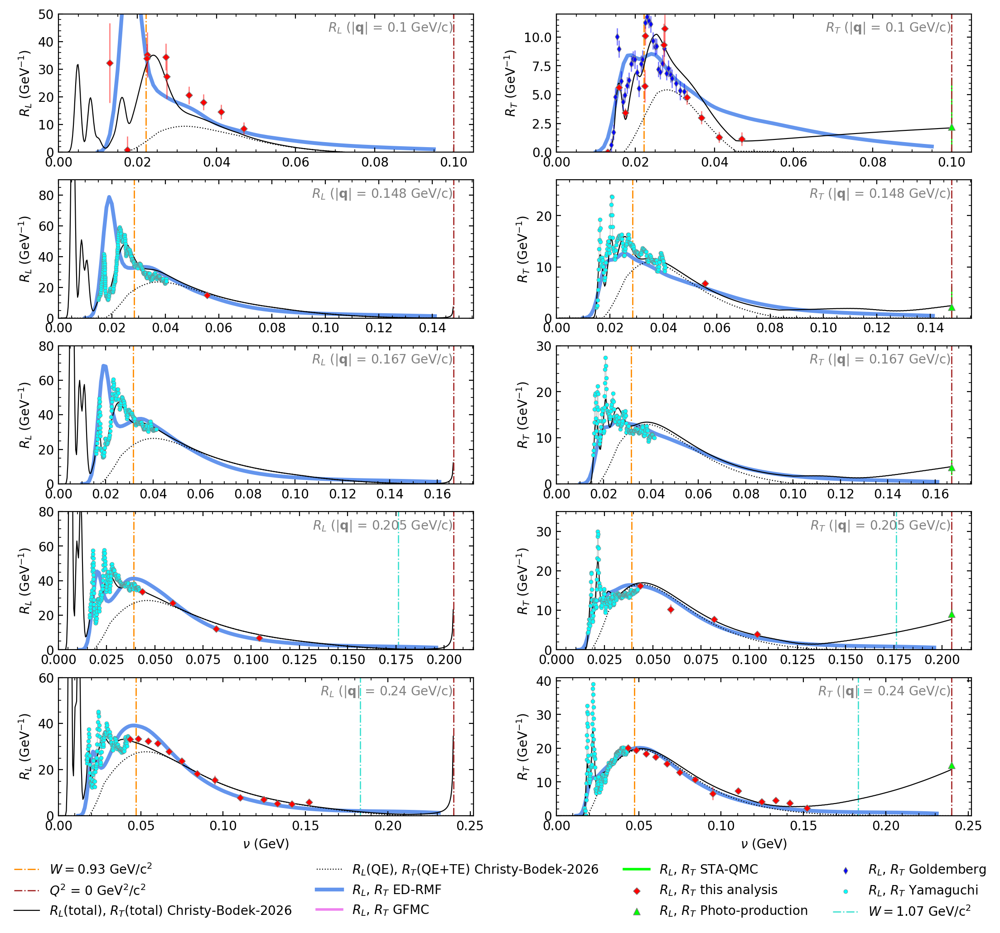

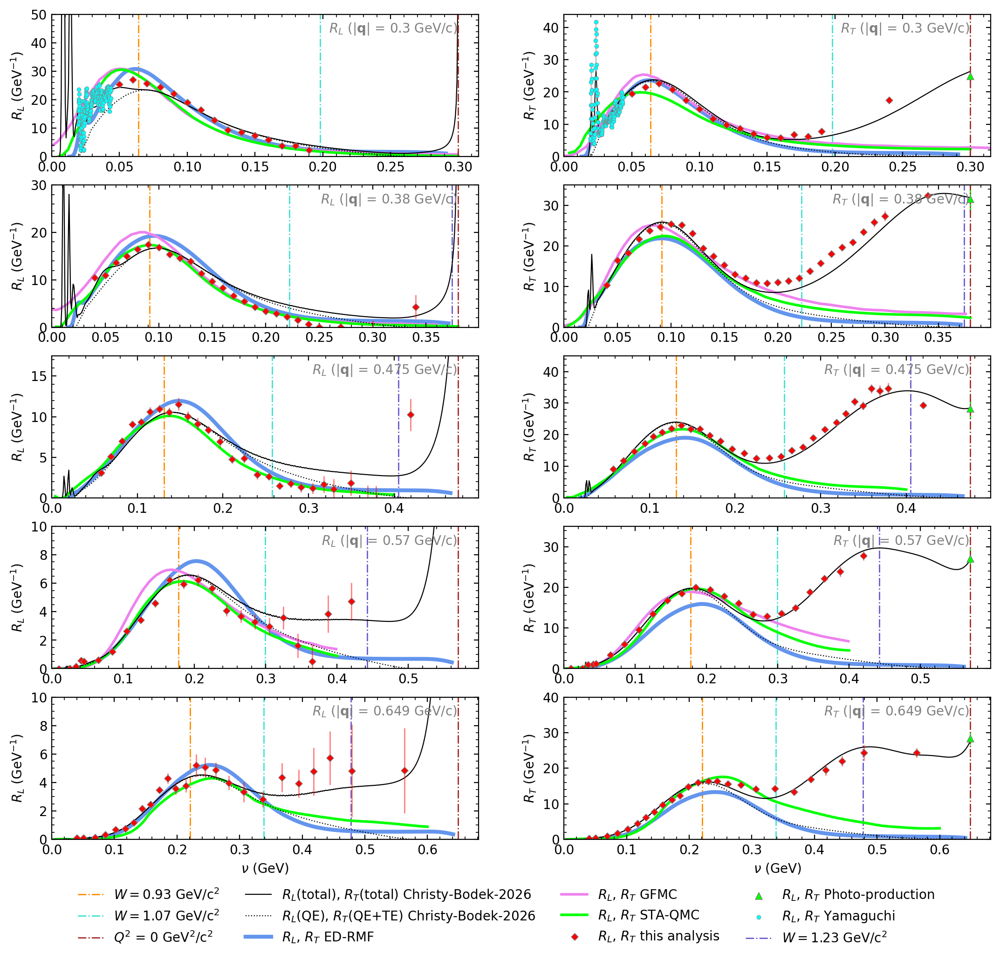

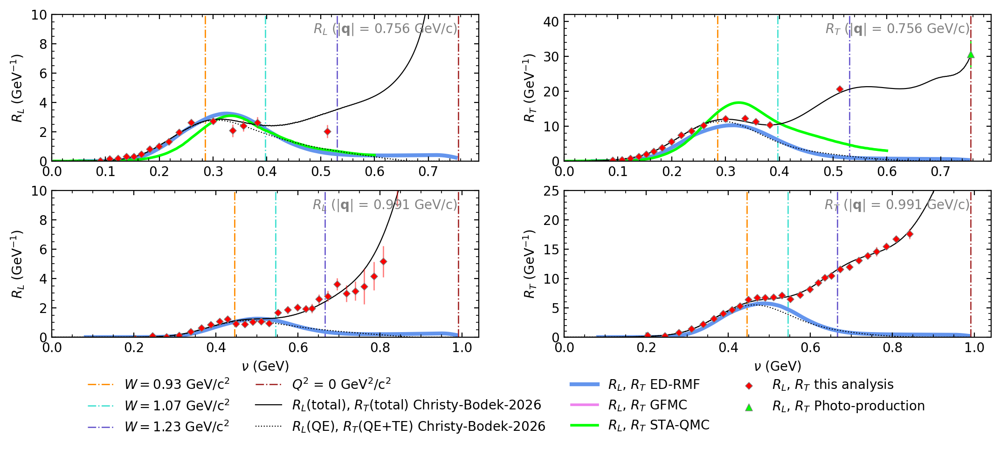

In [4]:
# fig 8, 9, 10
# for qvcenters in [QVCENTERS[0:5], QVCENTERS[5:10]]:
fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[0:5], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = ['Photo-production','Goldemberg', 'Yamaguchi'], theory_plot_list=['ED-RMF', 'GFMC', 'STA-QMC'], mc_plot_list=[])
save_to_pdf(fig, 'fig8.pdf')

fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[5:10], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = ['Photo-production','Goldemberg', 'Yamaguchi'], theory_plot_list=['ED-RMF', 'GFMC', 'STA-QMC'], mc_plot_list=[])
save_to_pdf(fig, 'fig9.pdf')

fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[10:12], figsize_per_row = (13, 1.5), figshow = True, bbox_to_anchor=(0.5, -0.15),
    exp_plot_list = ['Photo-production','Goldemberg', 'Yamaguchi'], theory_plot_list=['ED-RMF', 'GFMC', 'STA-QMC'], mc_plot_list=[])
save_to_pdf(fig, 'fig10.pdf')


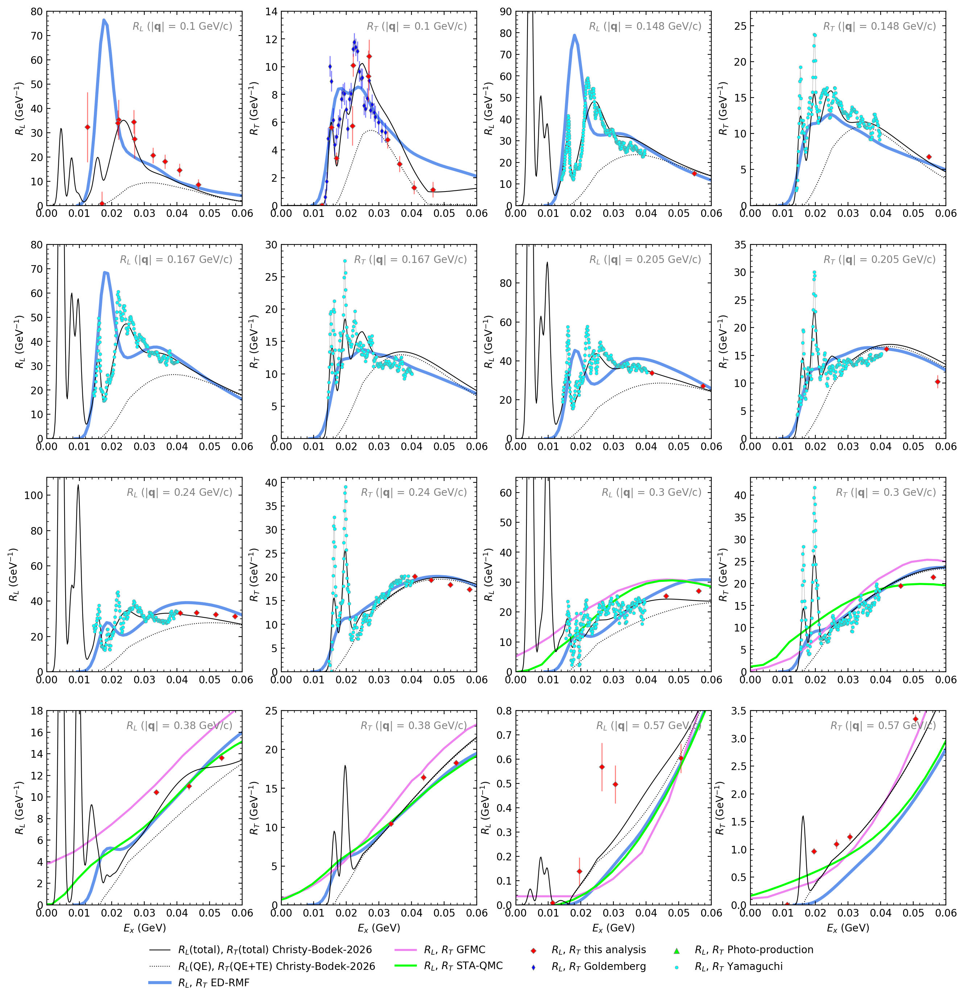

In [5]:
# fig 11
fig = plot_response_q2bin_ex_region(qtype='qv')
save_to_pdf(fig, 'fig11.pdf')

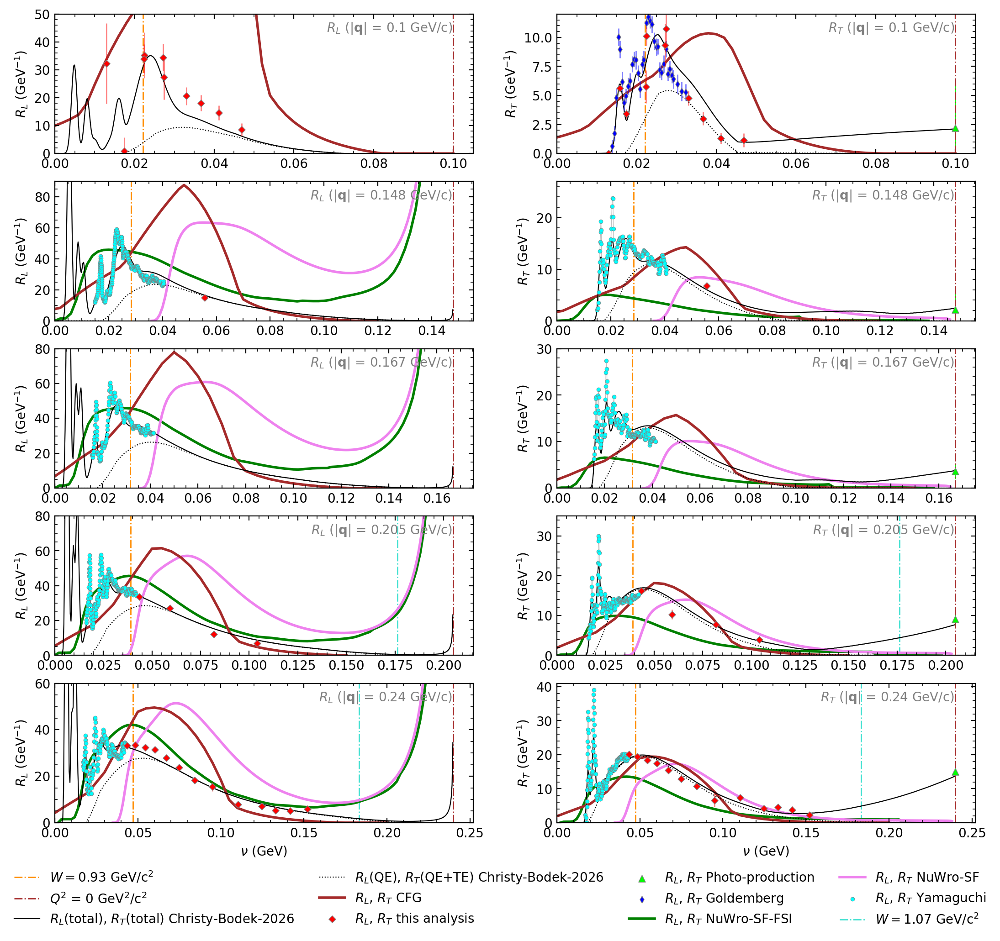

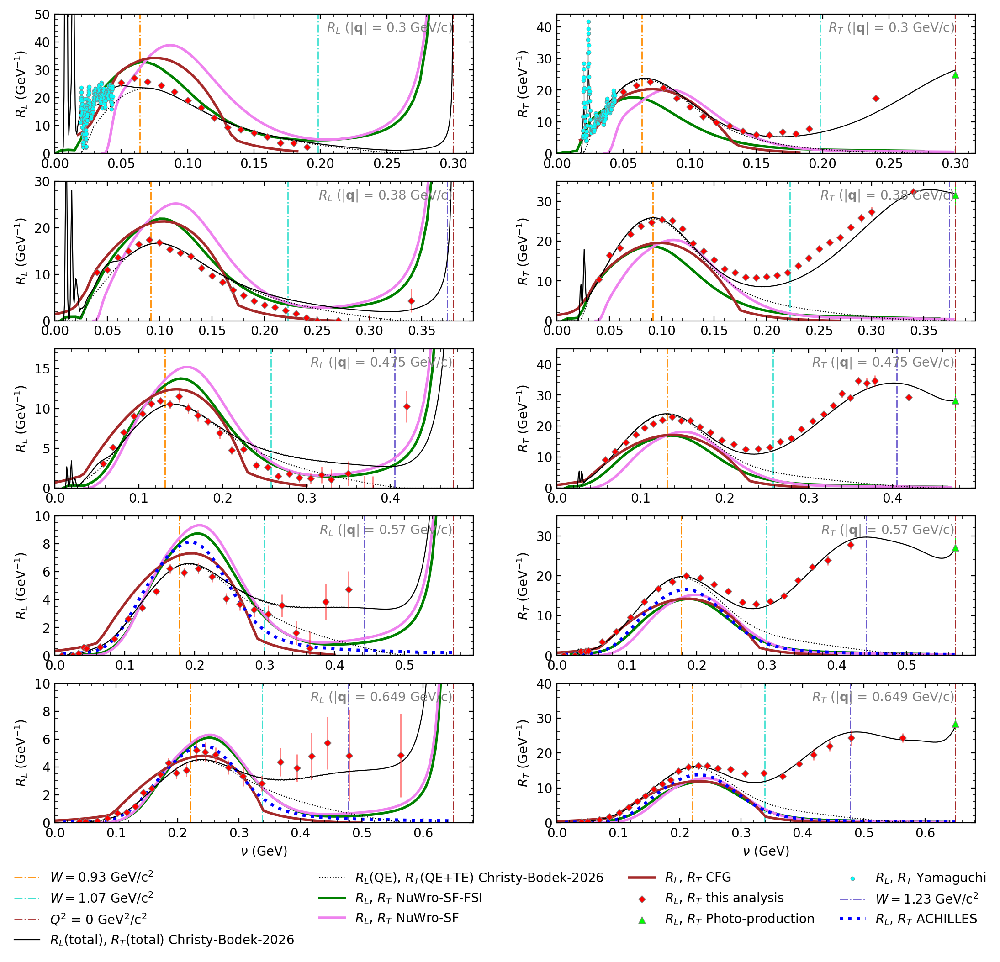

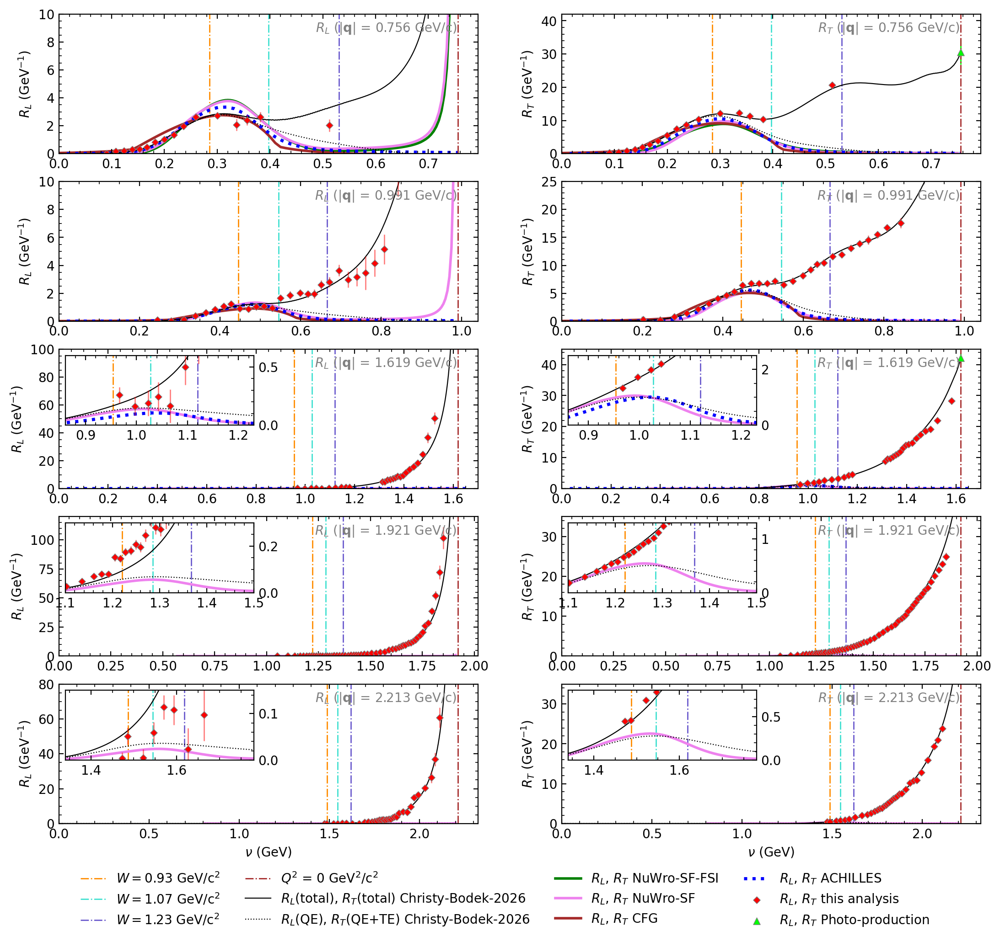

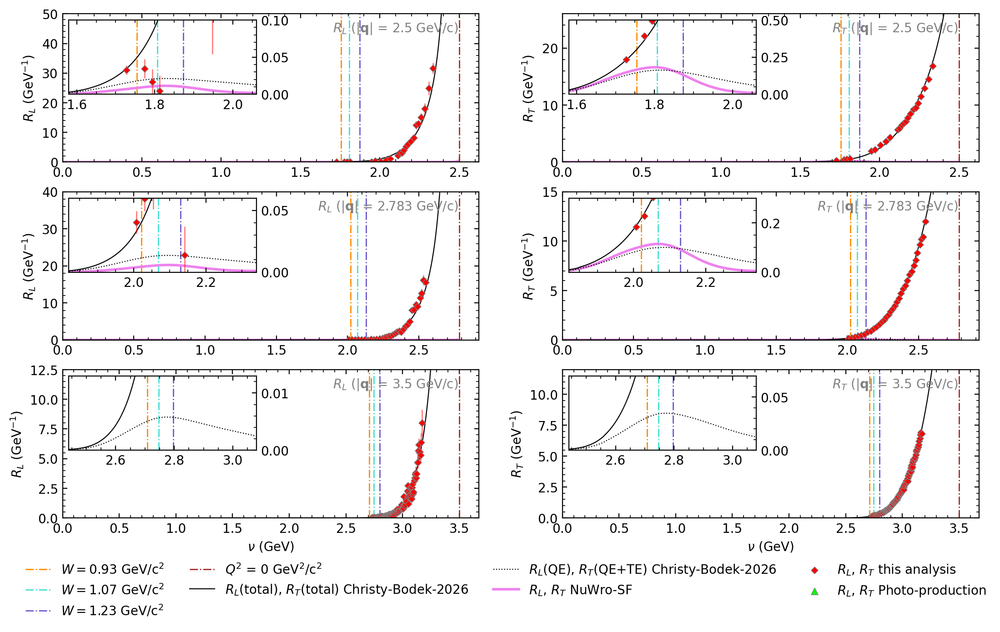

In [6]:
# fig 12, 13, 14, 15
exp_plot_list = ['Photo-production','Goldemberg', 'Yamaguchi']
theory_plot_list=[]
mc_plot_list=['SuSAv2', 'SuSAv2', 'NuWro-SF-FSI', 'NuWro-SF','CFG','ACHILLES']
fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[0:5], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig12.pdf')

fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[5:10], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, -0.02),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig13.pdf')

fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[10:15], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig14.pdf')

fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[15:18], figsize_per_row = (13, 1.9), figshow = True, bbox_to_anchor=(0.5, -0.06),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list,mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig15.pdf')


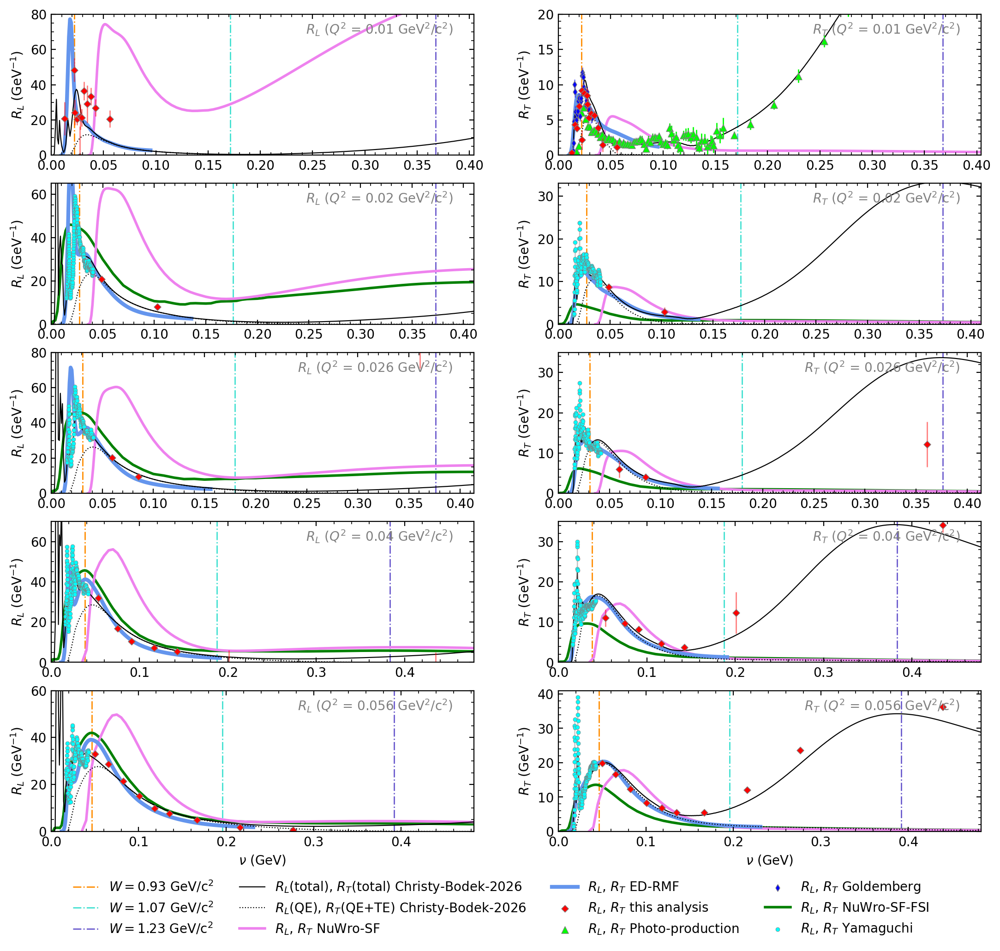

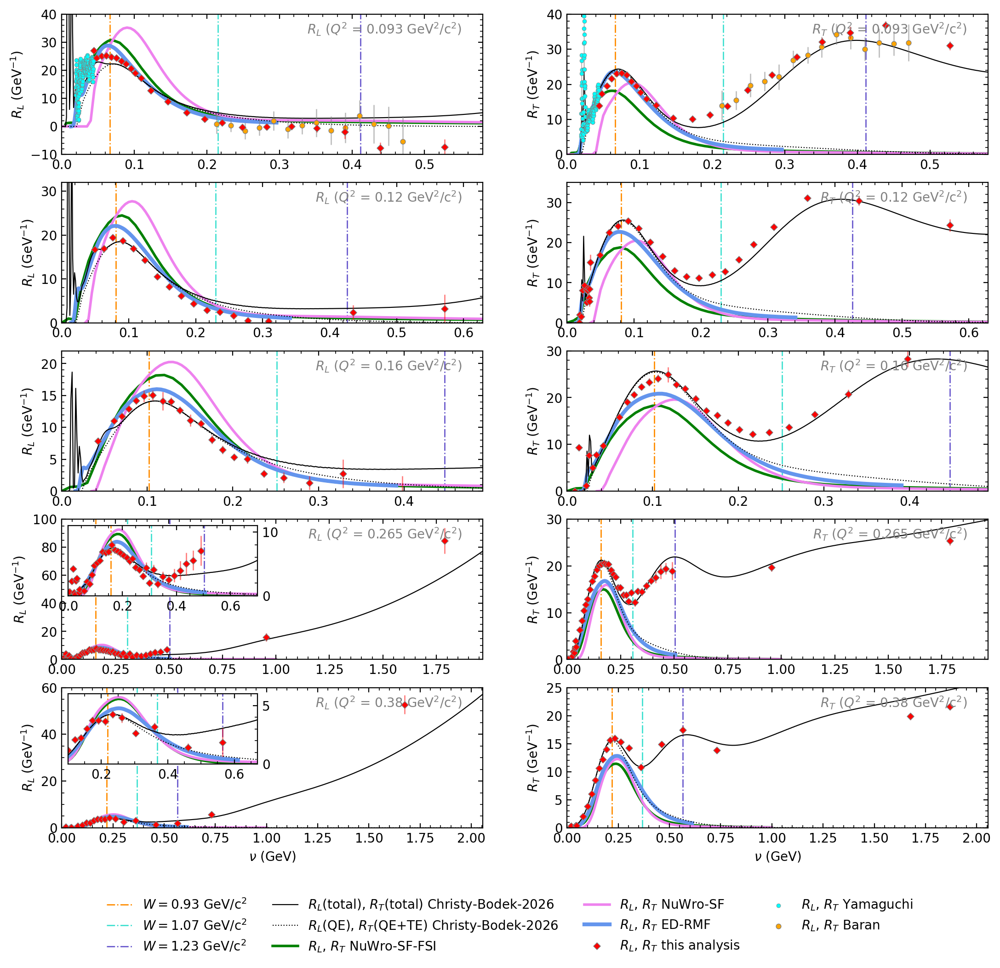

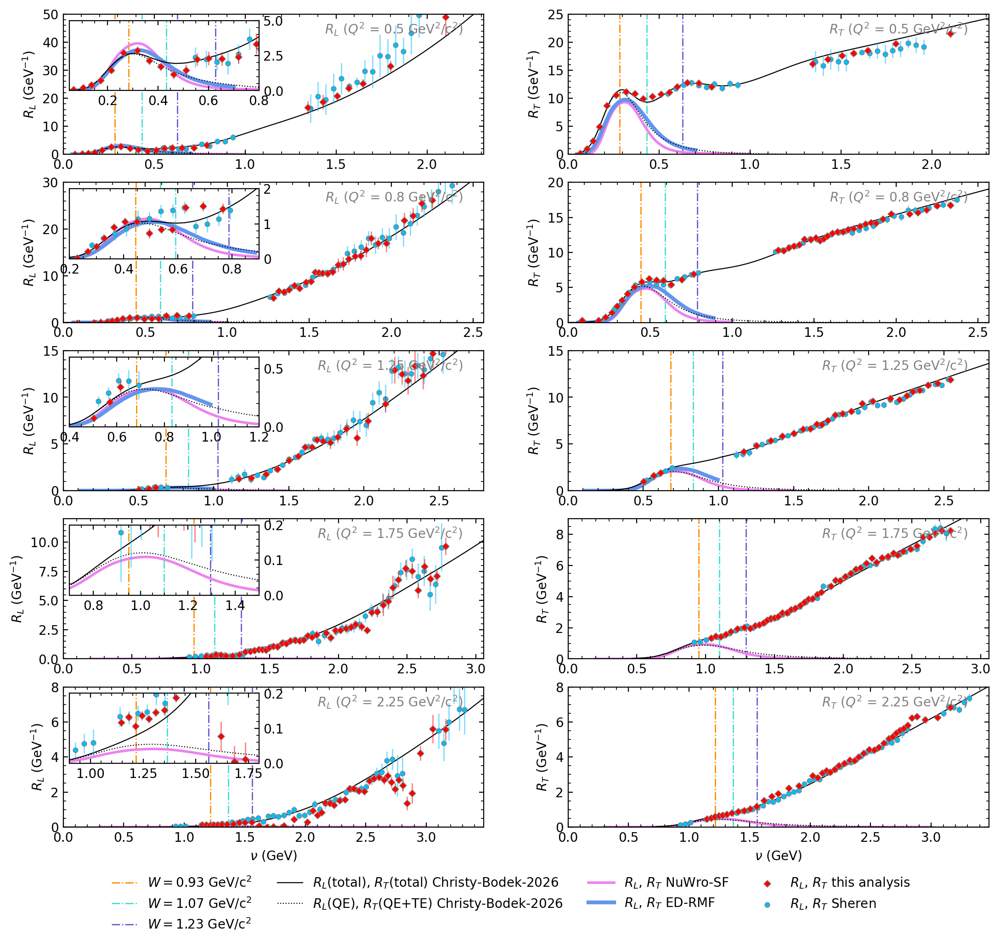

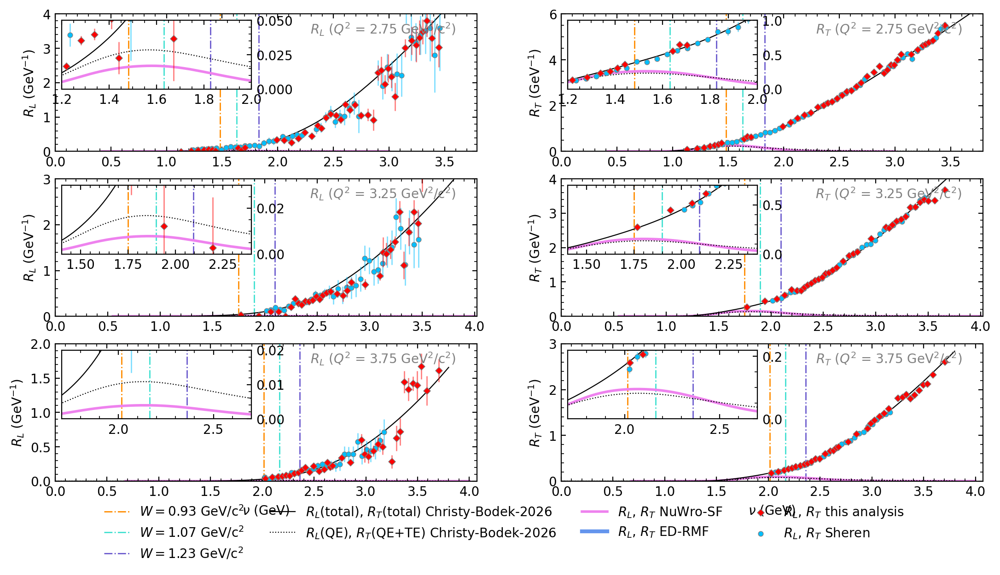

In [7]:
# fig 16, 17, 18, 19
exp_plot_list = ['Photo-production','Goldemberg', 'Yamaguchi','Sheren','Baran']
theory_plot_list=['ED-RMF']
mc_plot_list=['NuWro-SF-FSI', 'NuWro-SF']
fig = plot_response_q2bin(this_analysis_q2, q2centers = Q2CENTERS[0:5], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig16.pdf')

fig = plot_response_q2bin(this_analysis_q2, q2centers = Q2CENTERS[5:10], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, -0.02),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig17.pdf')

fig = plot_response_q2bin(this_analysis_q2, q2centers = Q2CENTERS[10:15], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig18.pdf')

fig = plot_response_q2bin(this_analysis_q2, q2centers = Q2CENTERS[15:18], figsize_per_row = (13, 1.7), figshow = True, bbox_to_anchor=(0.5, -0.04),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list,mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig19.pdf')


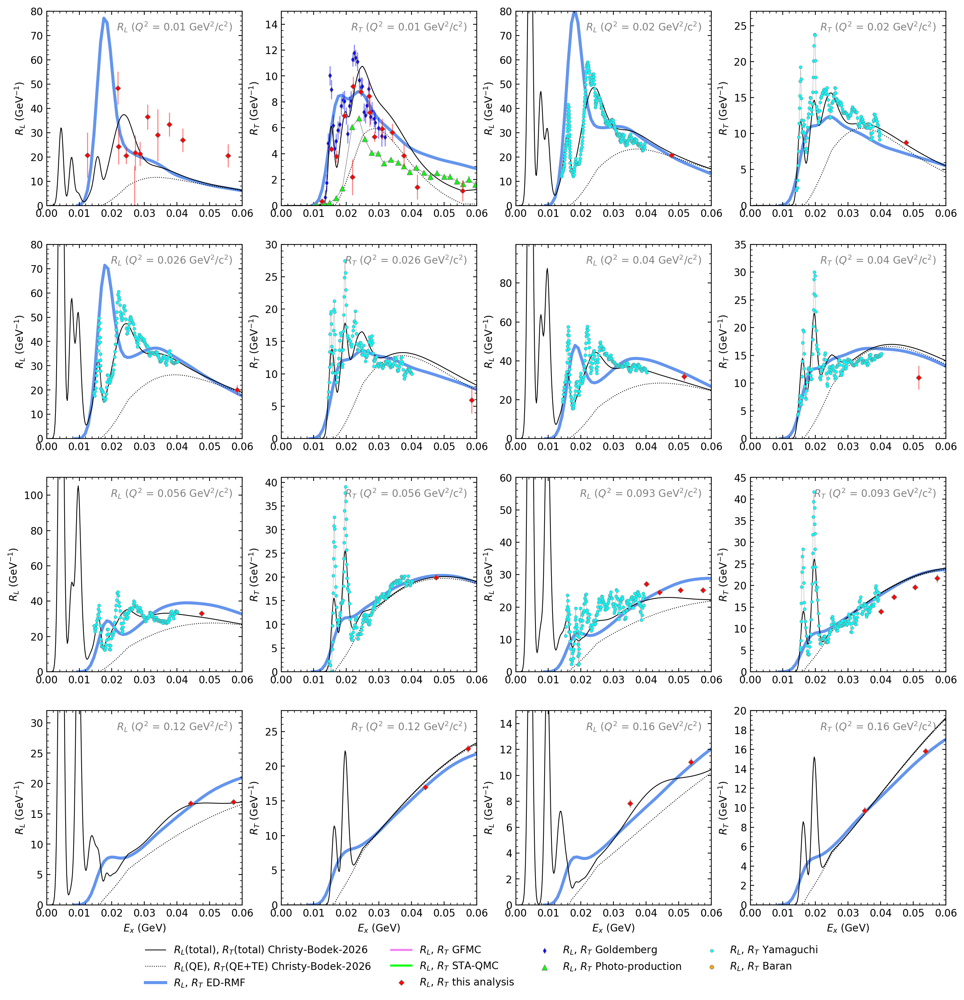

In [16]:
# fig 20
fig = plot_response_q2bin_ex_region(qtype='q2')
save_to_pdf(fig, 'fig20.pdf')



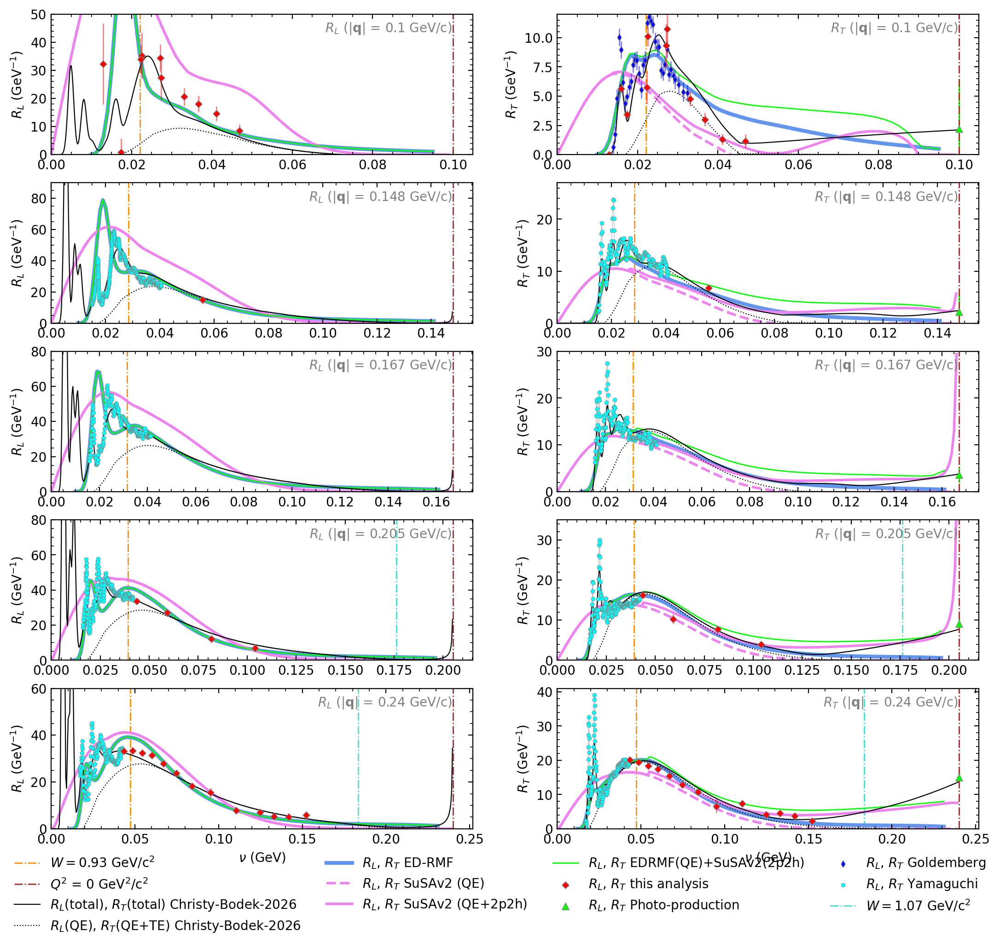

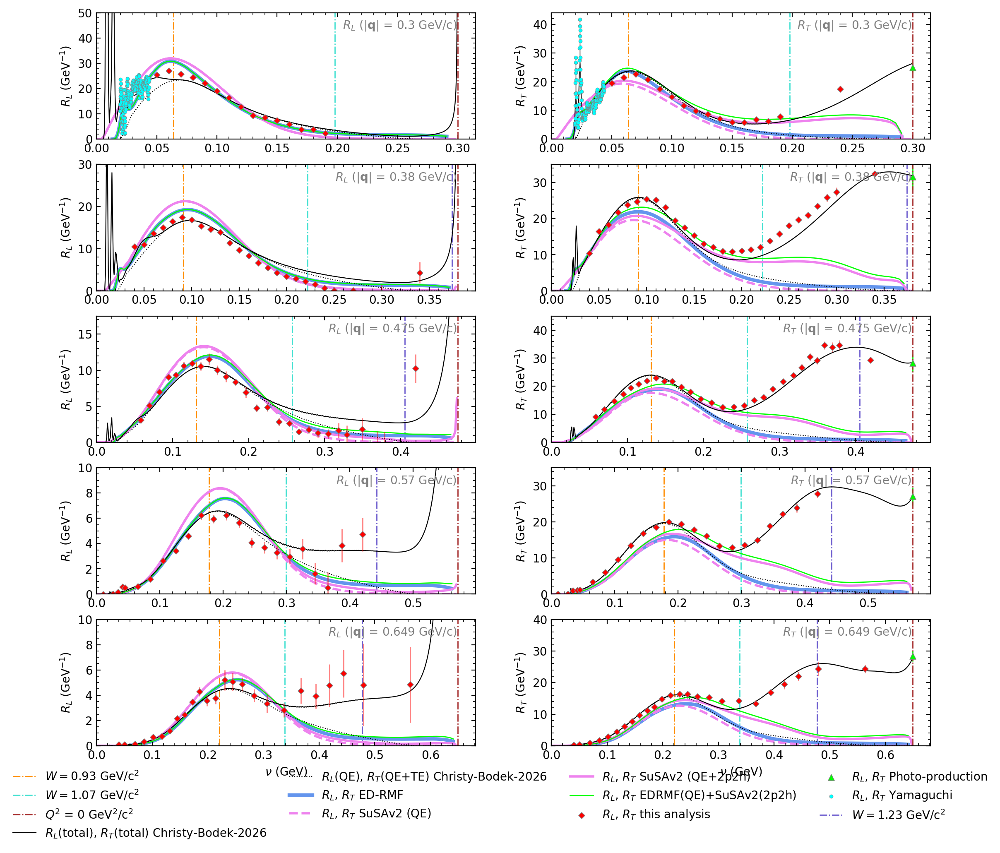

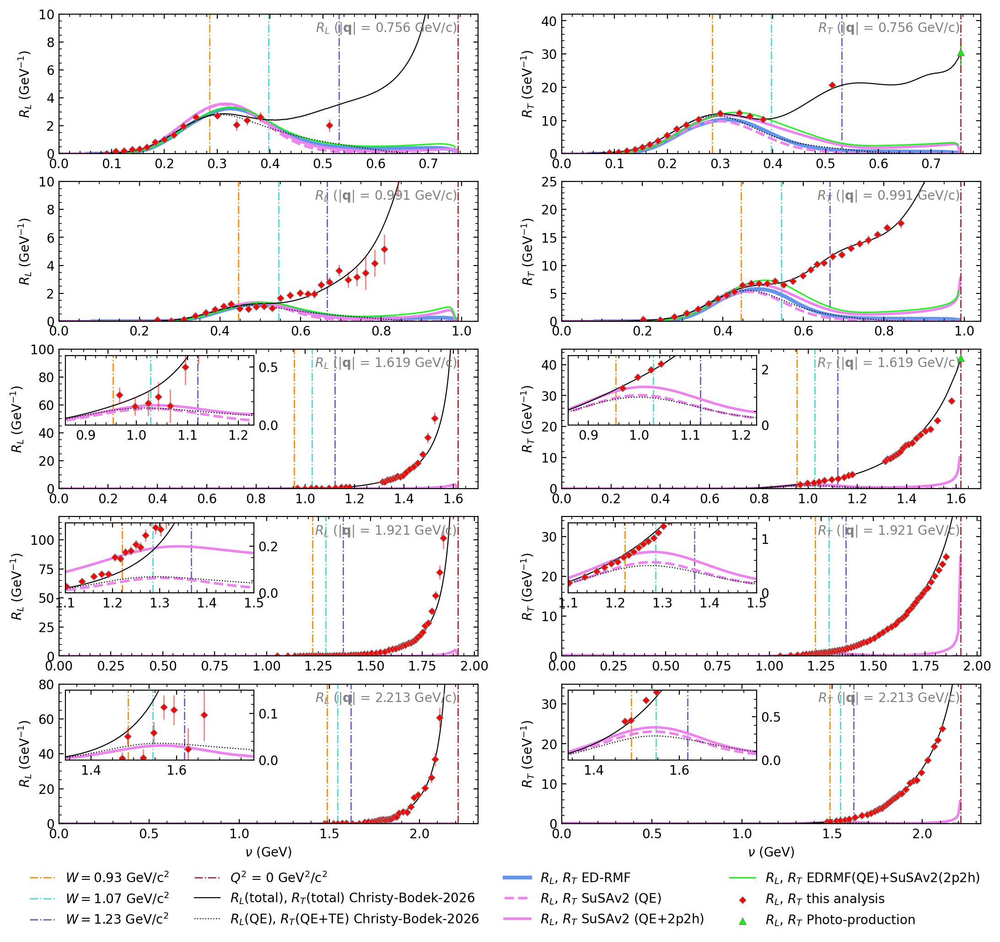

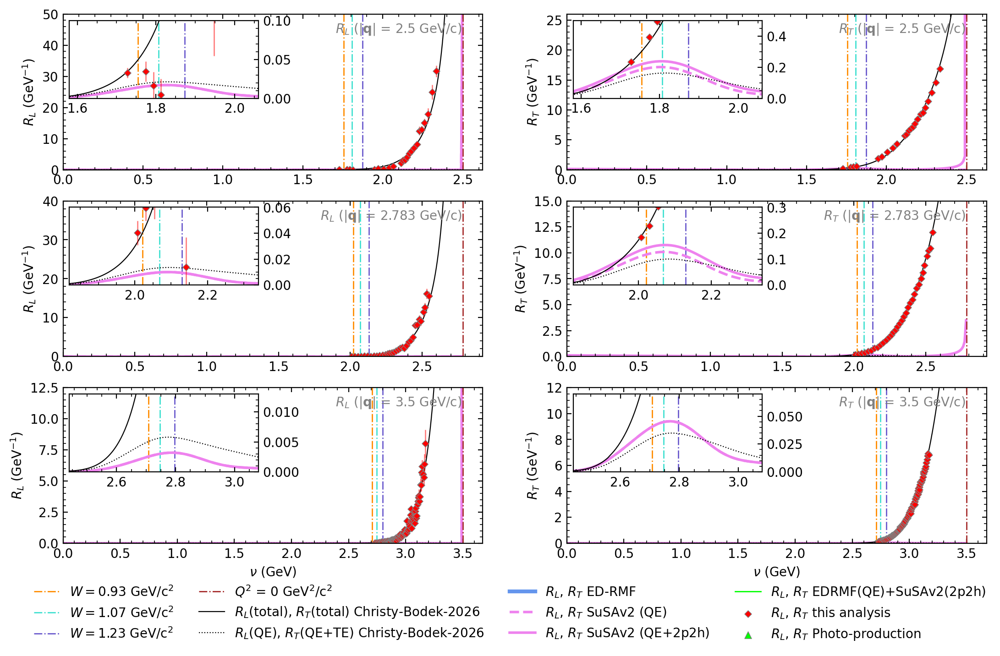

In [9]:
# fig 21, 22, 23, 24
exp_plot_list = ['Photo-production','Goldemberg', 'Yamaguchi','Sheren','Baran']
theory_plot_list=['ED-RMF', 'SuSAv2 qe', 'SuSAv2 qe+2p2h', 'EDRMF(QE)+SuSAv2(2p2h)']
mc_plot_list=[]
fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[0:5], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig21.pdf')

fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[5:10], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig22.pdf')

fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[10:15], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig23.pdf')

fig = plot_response_qvbin(this_analysis_qv, qvcenters = QVCENTERS[15:18], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, -0.05),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig24.pdf')


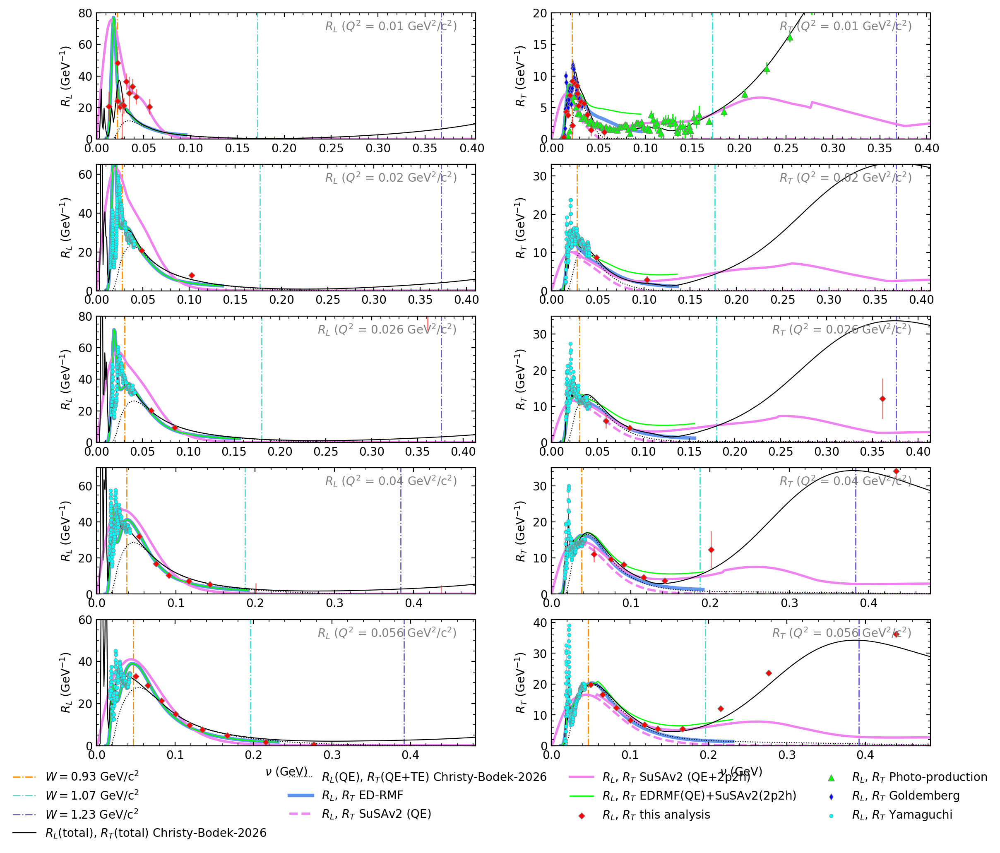

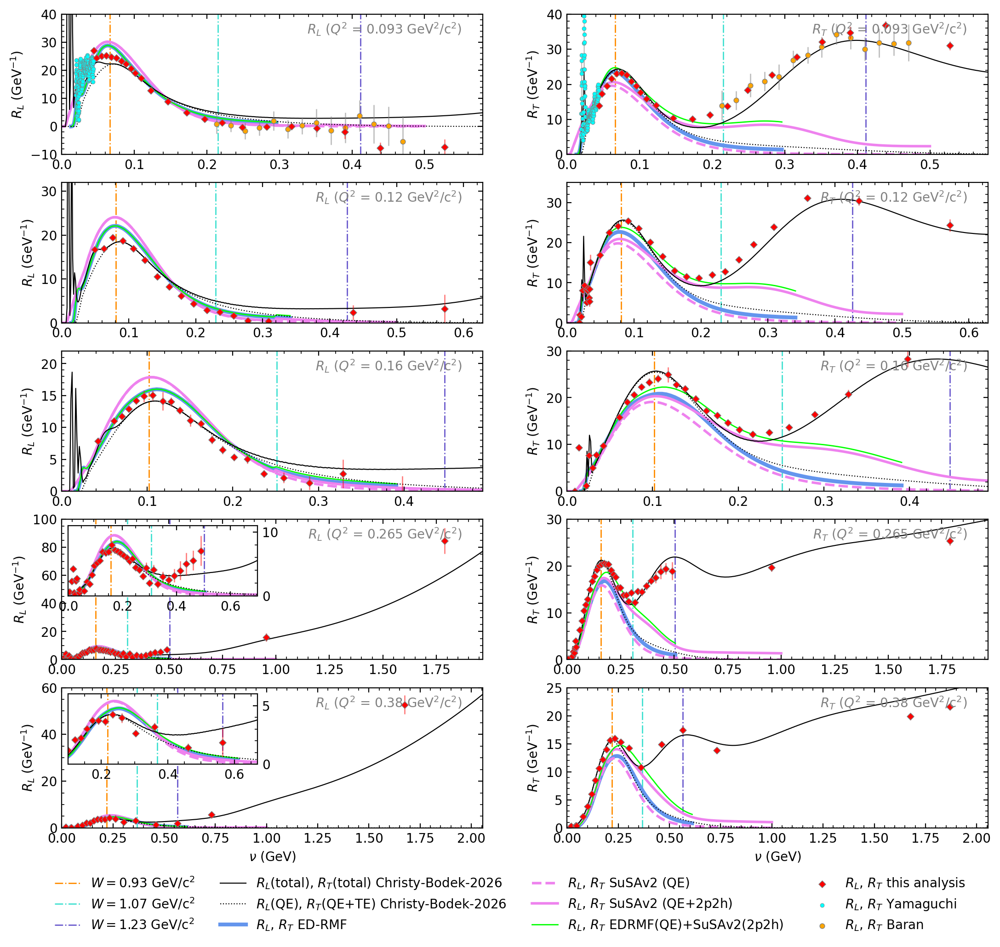

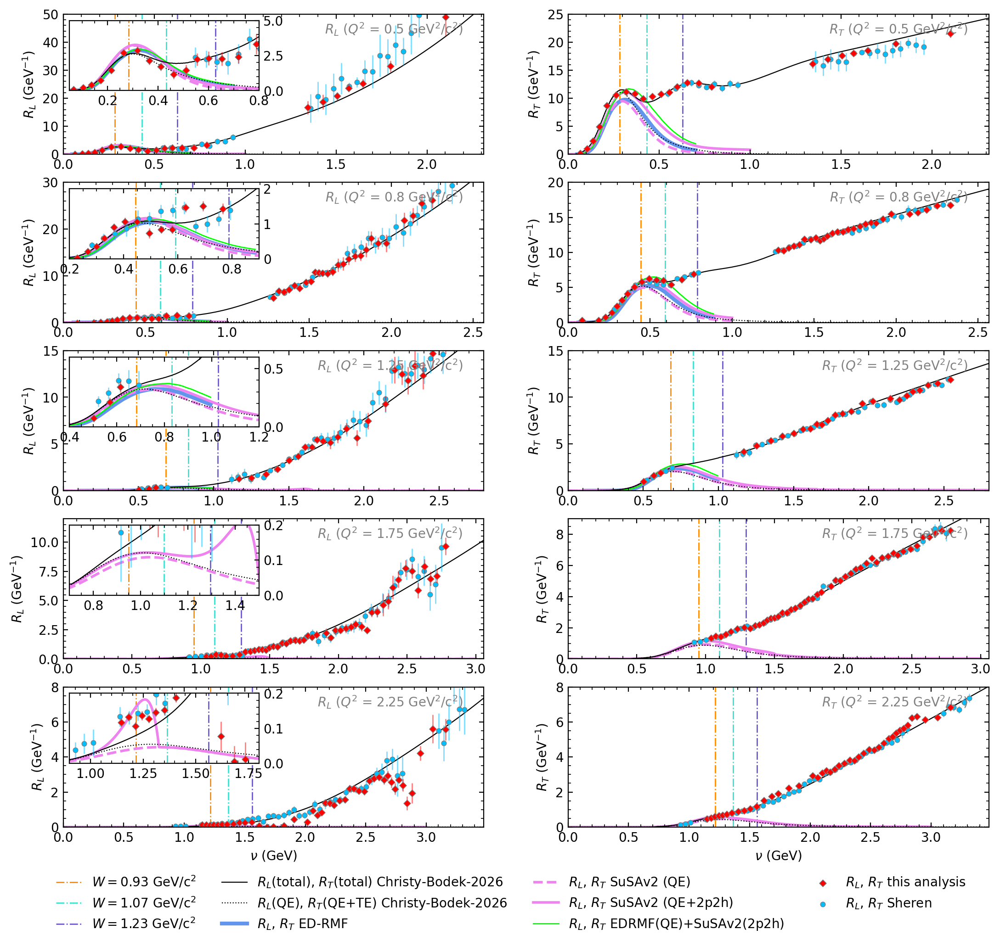

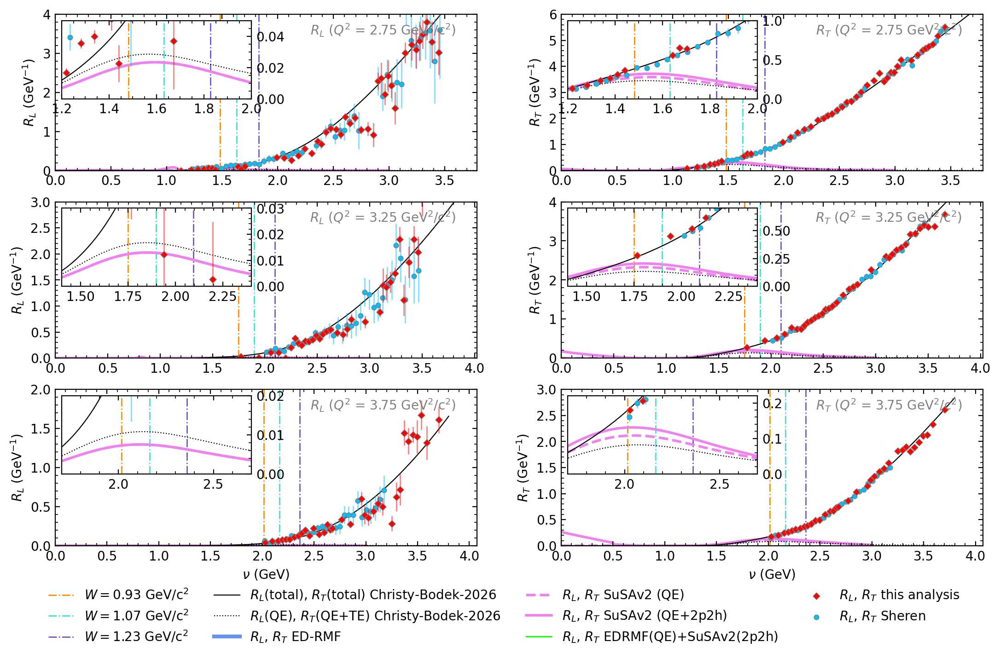

In [10]:
# fig 25, 26, 27, 28
exp_plot_list = ['Photo-production','Goldemberg', 'Yamaguchi','Sheren','Baran']
theory_plot_list=['ED-RMF', 'SuSAv2 qe', 'SuSAv2 qe+2p2h', 'EDRMF(QE)+SuSAv2(2p2h)']
mc_plot_list=[]
fig = plot_response_q2bin(this_analysis_q2, q2centers = Q2CENTERS[0:5], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig25.pdf')

fig = plot_response_q2bin(this_analysis_q2, q2centers = Q2CENTERS[5:10], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig26.pdf')

fig = plot_response_q2bin(this_analysis_q2, q2centers = Q2CENTERS[10:15], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, 0.0),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig27.pdf')

fig = plot_response_q2bin(this_analysis_q2, q2centers = Q2CENTERS[15:18], figsize_per_row = (13, 2), figshow = True, bbox_to_anchor=(0.5, -0.05),
    exp_plot_list = exp_plot_list, theory_plot_list=theory_plot_list, mc_plot_list=mc_plot_list)
save_to_pdf(fig, 'fig28.pdf')
